# Expected SARSA: bootstrap from the behavior-policy average

Expected SARSA replaces SARSA's sampled next action with its expectation:

$$y_t=R_{t+1}+\gamma(1-d_t)\sum_a\pi(a\mid S_{t+1})Q(S_{t+1},a),$$
$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\left[y_t-Q(S_t,A_t)\right].$$

Here $\pi$ is the epsilon-greedy behavior policy, $\alpha$ the learning rate, $\gamma$ the discount factor, and $d_t$ the terminal indicator. Averaging over actions removes variance from sampling one bootstrap action.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

ENV_ID = "FrozenLake-v1"
TOTAL_TIMESTEPS = 5_000
LEARNING_RATE = 0.2
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EXPLORATION_STEPS = 3_000
SEED = 7

env = gym.make(ENV_ID, is_slippery=False)
rng = np.random.default_rng(SEED)
q_table = np.zeros((env.observation_space.n, env.action_space.n))

## 1. Represent the epsilon-greedy policy

Every action receives probability $\varepsilon/|\mathcal A|$ and the greedy action receives the remaining $1-\varepsilon$. The same probabilities drive behavior and the expected target.

In [2]:
def epsilon_at(step):
    fraction = min(step / EXPLORATION_STEPS, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)


def action_probabilities(state, step):
    epsilon = epsilon_at(step)
    probabilities = np.full(q_table.shape[1], epsilon / q_table.shape[1])
    probabilities[np.argmax(q_table[state])] += 1 - epsilon
    return probabilities


def select_action(state, step, deterministic=False):
    if deterministic:
        return int(np.argmax(q_table[state]))
    return int(rng.choice(q_table.shape[1], p=action_probabilities(state, step)))

## 2. Compute the expected TD target

Only true termination removes the bootstrap. A Gymnasium time-limit truncation ends the episode but does not imply a terminal MDP state.

In [3]:
def update(state, action, reward, next_state, terminated, step):
    expected_next_value = action_probabilities(next_state, step) @ q_table[next_state]
    target = reward + GAMMA * (1 - terminated) * expected_next_value
    td_error = target - q_table[state, action]
    q_table[state, action] += LEARNING_RATE * td_error
    return td_error


def train(total_timesteps):
    episode_returns = []
    episode_return = 0.0
    state, _ = env.reset(seed=SEED)
    for step in range(total_timesteps):
        action = select_action(state, step)
        next_state, reward, terminated, truncated, _ = env.step(action)
        update(state, action, reward, next_state, terminated, step + 1)
        episode_return += reward
        if terminated or truncated:
            episode_returns.append(episode_return)
            episode_return = 0.0
            state, _ = env.reset()
        else:
            state = next_state
    return episode_returns


episode_returns = train(TOTAL_TIMESTEPS)
env.close()

## 3. Plot learning

The moving average estimates the recent success rate on deterministic FrozenLake.

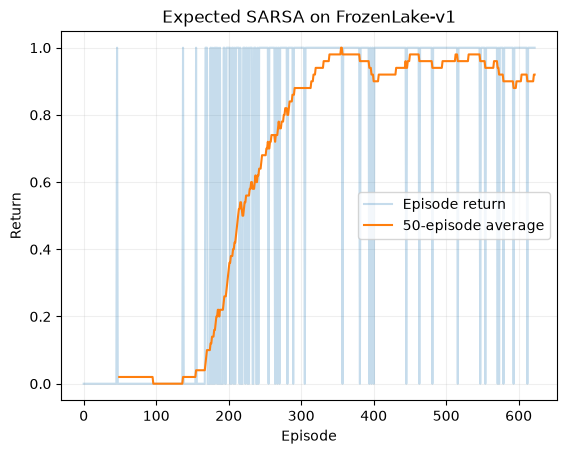

In [4]:
window = min(50, len(episode_returns))
moving_average = np.convolve(episode_returns, np.ones(window) / window, mode="valid")
plt.plot(episode_returns, alpha=0.25, label="Episode return")
plt.plot(np.arange(window - 1, len(episode_returns)), moving_average, label=f"{window}-episode average")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Expected SARSA on FrozenLake-v1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4. Evaluate the greedy policy

This opens a separate rendered environment and disables exploration for 5 episodes.

In [5]:
evaluation_env = gym.make(ENV_ID, render_mode="human", is_slippery=False)
evaluation_returns = []
try:
    for episode in range(5):
        state, _ = evaluation_env.reset(seed=10 + episode)
        total_reward = 0.0
        done = False
        while not done:
            action = select_action(state, TOTAL_TIMESTEPS, deterministic=True)
            state, reward, terminated, truncated, _ = evaluation_env.step(action)
            total_reward += reward
            done = terminated or truncated
        evaluation_returns.append(total_reward)
finally:
    evaluation_env.close()
print("Episode returns:", evaluation_returns)

Episode returns: [1.0, 1.0, 1.0, 1.0, 1.0]
